In [143]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

from category_encoders import JamesSteinEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from datetime import date
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

def add_velocity_features(df, cc_col='cc_num',
                           time_col='trans_date_trans_time',
                           amt_col='amt'):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([cc_col, time_col]).reset_index(drop=True)

    df['tx_count_1h'] = (
        df.groupby(cc_col)[time_col]
        .transform(lambda x: x.expanding().count()
                   - x.shift(1).fillna(x.iloc[0])
                   .transform(lambda _: 0))
    )

    # cleaner approach: use a time-indexed rolling per group
    results = []
    for card, group in df.groupby(cc_col):
        group = group.set_index(time_col)
        group['tx_count_1h']  = group[amt_col].rolling('1h').count()
        group['tx_count_24h'] = group[amt_col].rolling('24h').count()
        group['amt_sum_24h']  = group[amt_col].rolling('24h').sum()


        results.append(group.reset_index())

    return pd.concat(results).sort_index()


def evaluate_velocity_features(df, target_col='is_fraud'):
    feat_cols = ['tx_count_1h', 'tx_count_24h', 'amt_sum_24h']
    X = df[feat_cols].fillna(0)
    y = df[target_col]

    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    mi_scores = pd.Series(mi, index=feat_cols).sort_values(ascending=False)

    print("── Mutual Information vs is_fraud ──")
    print(mi_scores.round(4))
    print()

    print("── Mean feature value: fraud vs legit ──")
    print(df.groupby(target_col)[feat_cols].mean().round(3))

    return mi_scores

In [144]:
data = pd.read_csv("./fraudTrain.csv", index_col=0)




In [145]:
data.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [146]:
data.drop(columns=["first","last"] , inplace=True)
data['distance_km'] = haversine_vectorized(data['lat'], data['long'], data['merch_lat'], data['merch_long'])
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance_km
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,78.597568
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,30.212176
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,108.206083
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,95.673231
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,77.556744


In [147]:
data.nunique()


trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
distance_km              1296675
dtype: int64

In [148]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,distance_km
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,7.611465e+01
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.911693e+01
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,2.225452e-02
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,5.533491e+01
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,7.823175e+01
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,9.850327e+01
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,1.521172e+02


In [149]:
data['distance_km'] = haversine_vectorized(data['lat'], data['long'], data['merch_lat'], data['merch_long'])

In [150]:
data.drop(columns=["trans_num","unix_time","merch_lat","merch_long"] , inplace=True)

In [151]:
data.columns


Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'is_fraud', 'distance_km'],
      dtype='object')

In [152]:
data["is_fraud"]

0          0
1          0
2          0
3          0
4          0
          ..
1296670    0
1296671    0
1296672    0
1296673    0
1296674    0
Name: is_fraud, Length: 1296675, dtype: int64

In [153]:
data["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [154]:
data.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
is_fraud                   int64
distance_km              float64
dtype: object

In [155]:

fraud = data[data['is_fraud'] == 1]
non_fraud = data[data['is_fraud'] == 0]

# 2. Randomly sample non-fraud to match the number of fraud cases (50/50 ratio)
# You can also use 'n=len(fraud) * 10' for a 10/90 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud), random_state=42)

# 3. Combine back into a small, balanced plotting dataframe
plot_df = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1) 

data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,is_fraud,distance_km
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0,78.597568
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,0,30.212176
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,0,108.206083
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,0,95.673231
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,0,77.556744


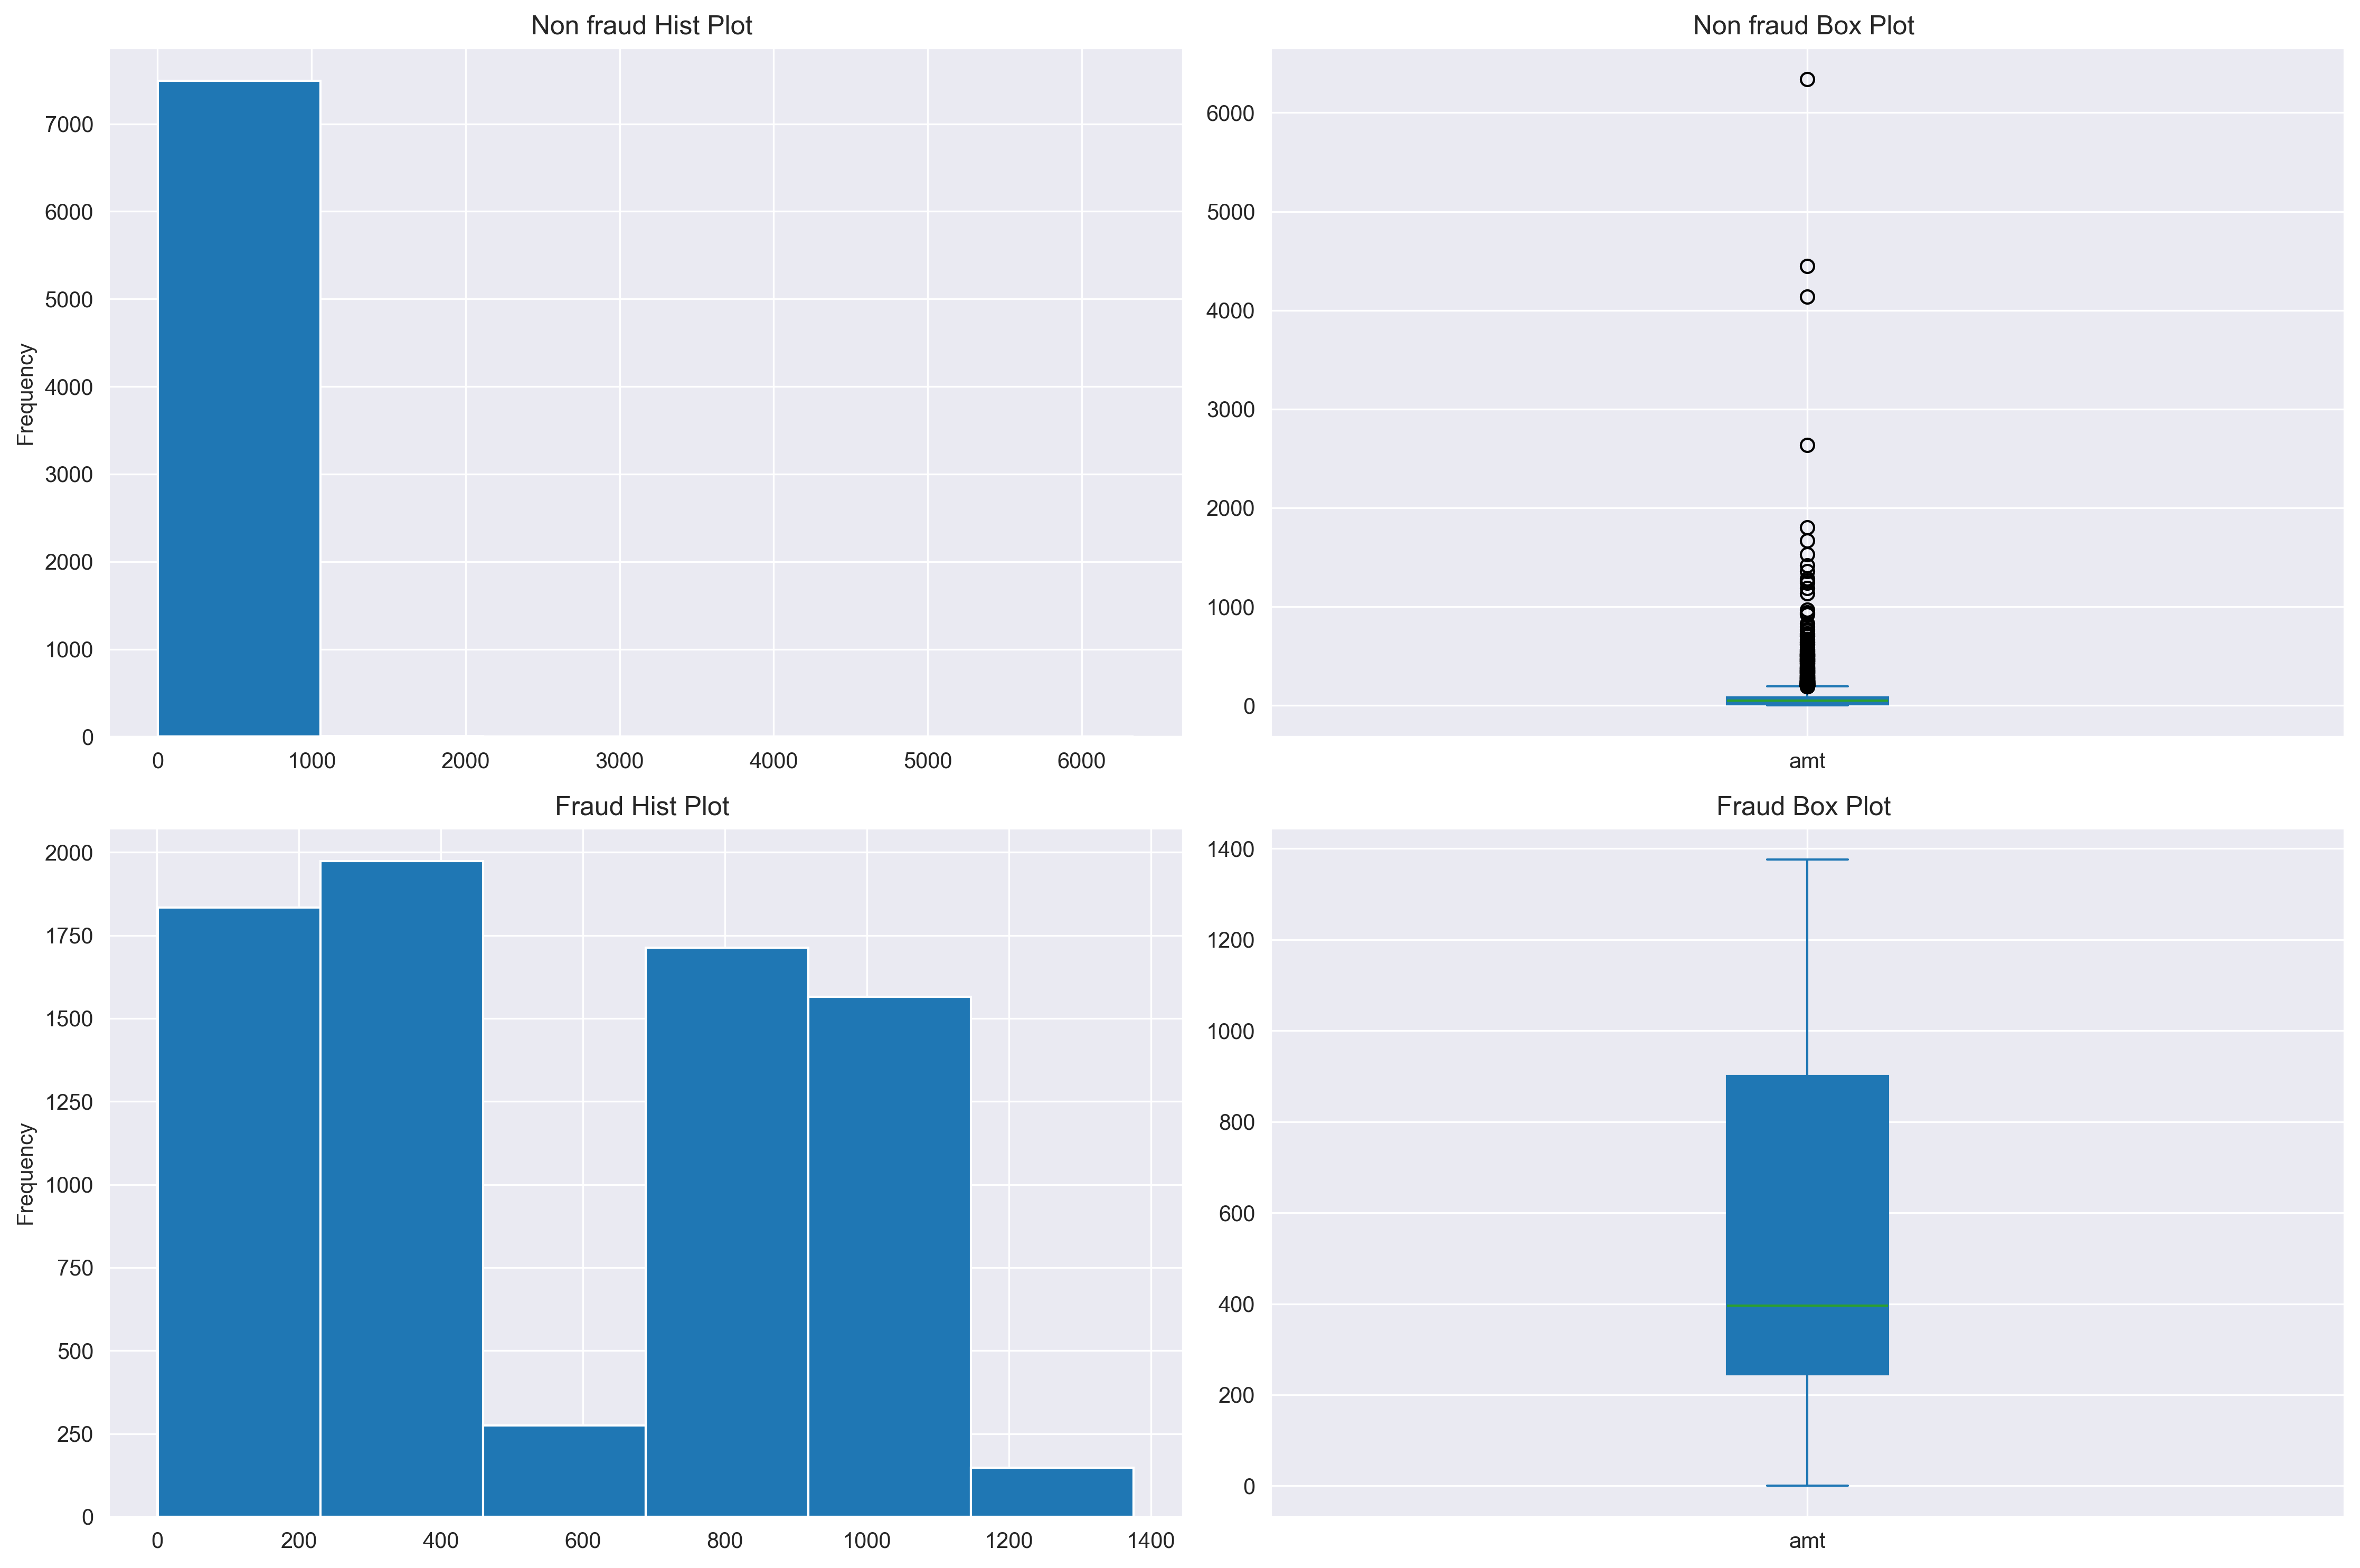

count    7506.000000
mean       67.715905
std       140.102743
min         1.000000
25%         9.710000
50%        47.925000
75%        83.412500
max      6337.250000
Name: amt, dtype: float64
99% of the data lies between 1.12 and 597.967500000007


In [156]:
fig, ((ax1,ax2), (ax3,ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(15, 10),dpi=300)
(non_fraud_downsampled["amt"].plot(kind='hist', ax=ax1, bins=6))
fig.set_label('Amount distribution for non fraud transactions')
ax1.set_title('Non fraud Hist Plot ')



# 4. Plot the box plot on the second subplot (ax2)
non_fraud_downsampled["amt"].plot(kind='box', ax=ax2, patch_artist=True)
ax2.set_title('Non fraud Box Plot ')

(fraud["amt"].plot(kind='hist', ax=ax3, bins=6))
fig.set_label('Amount distribution for fraud transactions')
ax3.set_title('Fraud Hist Plot ')



# 4. Plot the box plot on the second subplot (ax2)
fraud["amt"].plot(kind='box', ax=ax4, patch_artist=True)
ax4.set_title('Fraud Box Plot ')


# 5. Optimize layout spacing and display
plt.tight_layout()
plt.show()

#non_fraud_downsampled["amt"].plot.hist()
print(non_fraud_downsampled["amt"].describe())
lower_bound = non_fraud_downsampled['amt'].quantile(0.005)
upper_bound = non_fraud_downsampled['amt'].quantile(0.995)

print(f"99% of the data lies between {lower_bound} and {upper_bound}")



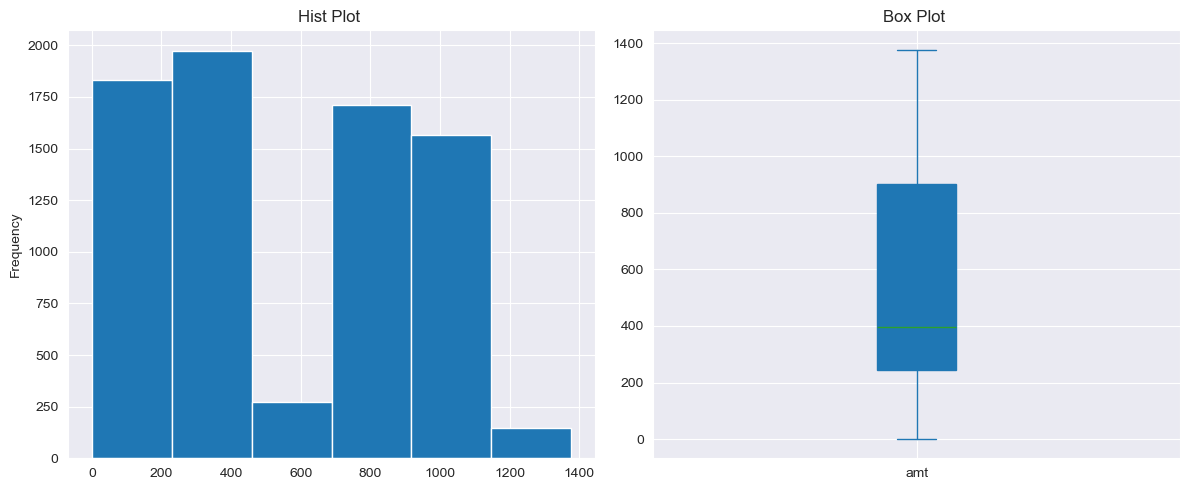

count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64
99% of the data lies between 6.0005 and 1215.4595000000004


<Axes: ylabel='Frequency'>

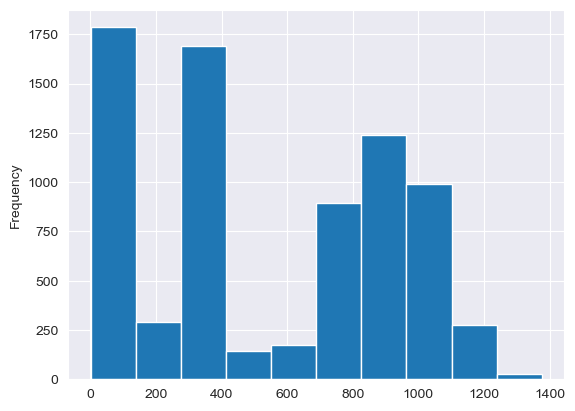

In [157]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
(fraud["amt"].plot(kind='hist', ax=ax1, bins=6))
fig.set_label('Amount distribution for fraud transactions')
ax1.set_title('Hist Plot ')



# 4. Plot the box plot on the second subplot (ax2)
fraud["amt"].plot(kind='box', ax=ax2, patch_artist=True)
ax2.set_title('Box Plot ')

# 5. Optimize layout spacing and display
plt.tight_layout()
plt.show()
#non_fraud_downsampled[


print(fraud["amt"].describe())
lower_bound = fraud['amt'].quantile(0.005)
upper_bound = fraud['amt'].quantile(0.995)

print(f"99% of the data lies between {lower_bound} and {upper_bound}")
fraud["amt"].plot.hist()

<Axes: ylabel='Frequency'>

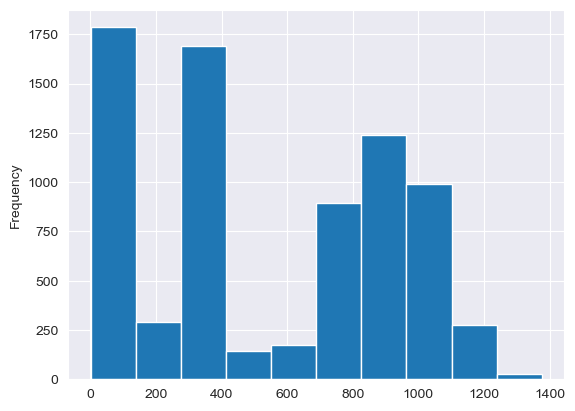

In [158]:
fraud["amt"].plot.hist()

In [159]:

train_vel = add_velocity_features(plot_df)
mi_scores = evaluate_velocity_features(train_vel)

── Mutual Information vs is_fraud ──
amt_sum_24h     0.5871
tx_count_24h    0.4830
tx_count_1h     0.1778
dtype: float64

── Mean feature value: fraud vs legit ──
          tx_count_1h  tx_count_24h  amt_sum_24h
is_fraud                                        
0               1.001         1.030       72.261
1               1.676         4.714     2422.725


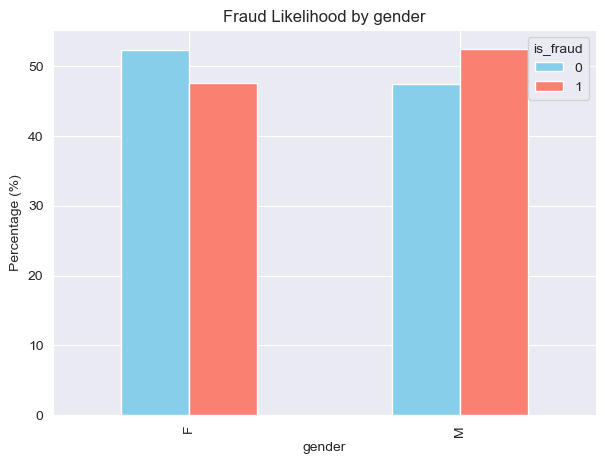

In [160]:


def plot_bar(df , col , width=7):
    counts = pd.crosstab(df[col], df['is_fraud'])
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    percentages.plot.bar(stacked=False, color=['skyblue', 'salmon'],figsize=(width,5))
    plt.ylabel('Percentage (%)')
    plt.title(f'Fraud Likelihood by {col}')
    plt.show()
  

def sample_and_plot(df , col , width=7 , nsamples=100):
    top_fraud_col = df[col].value_counts().nlargest(nsamples).index
    filtered_df = df[plot_df[col].isin(top_fraud_col)]
    plot_bar(filtered_df,col,width)

plot_bar(plot_df ,"gender")

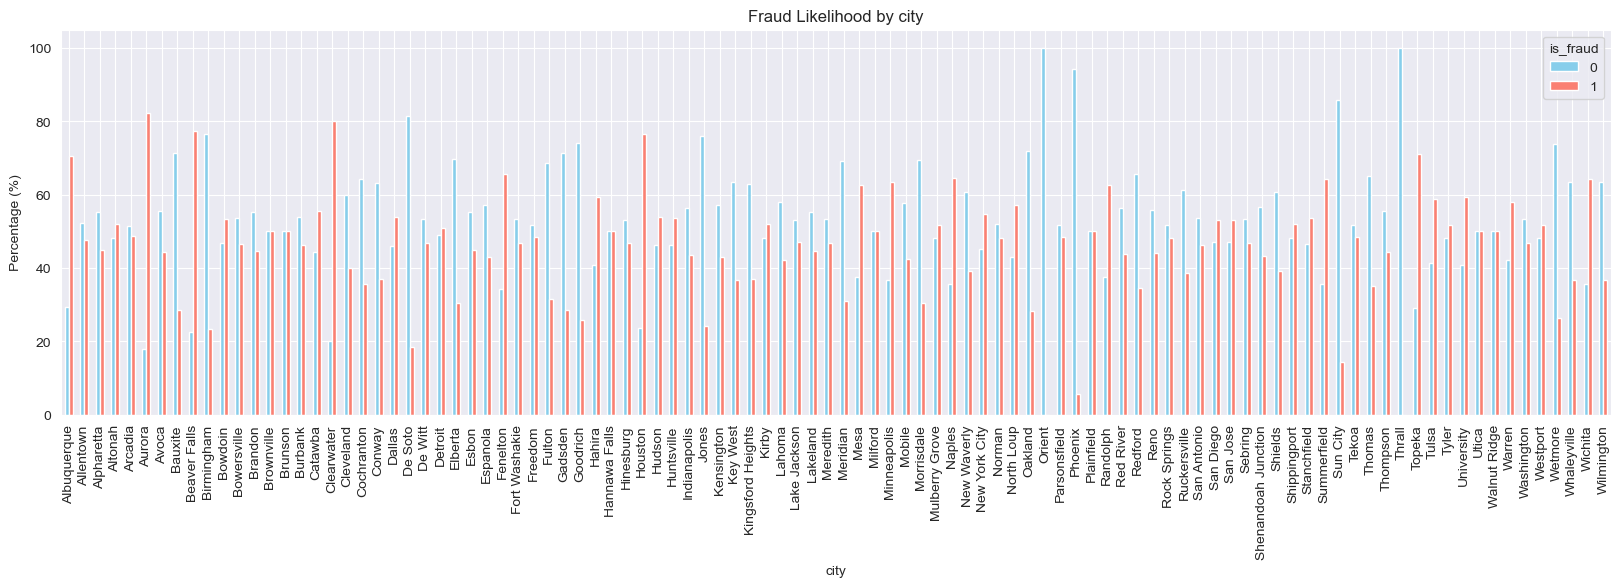

In [161]:

sample_and_plot(plot_df ,'city',20,100)

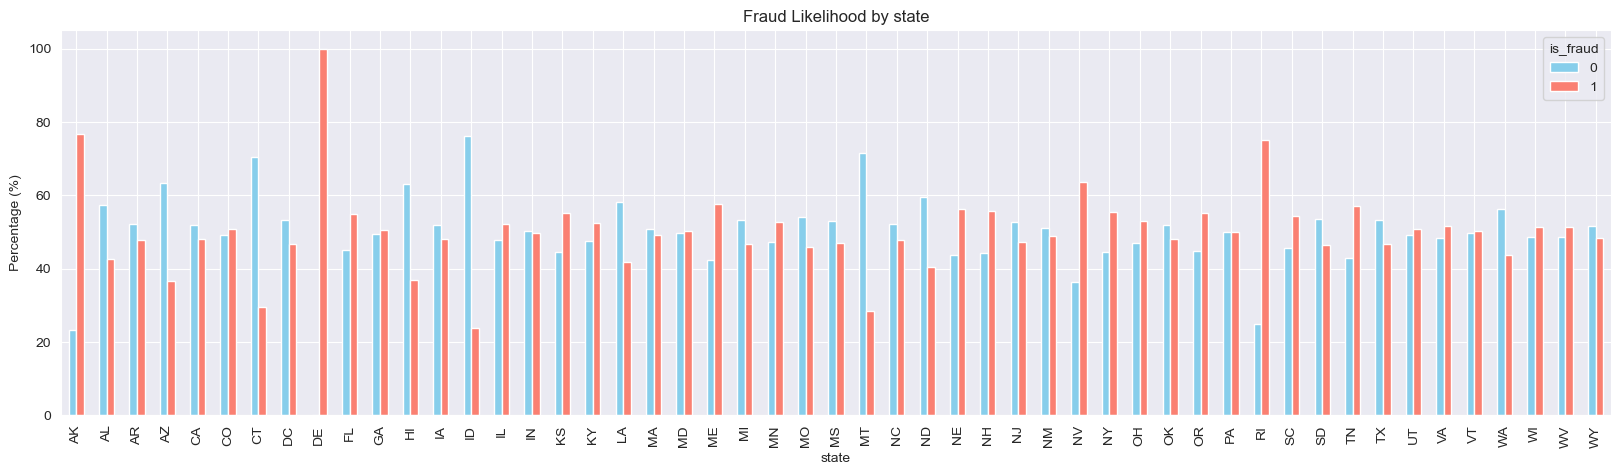

In [162]:

sample_and_plot(plot_df ,'state',20,100)

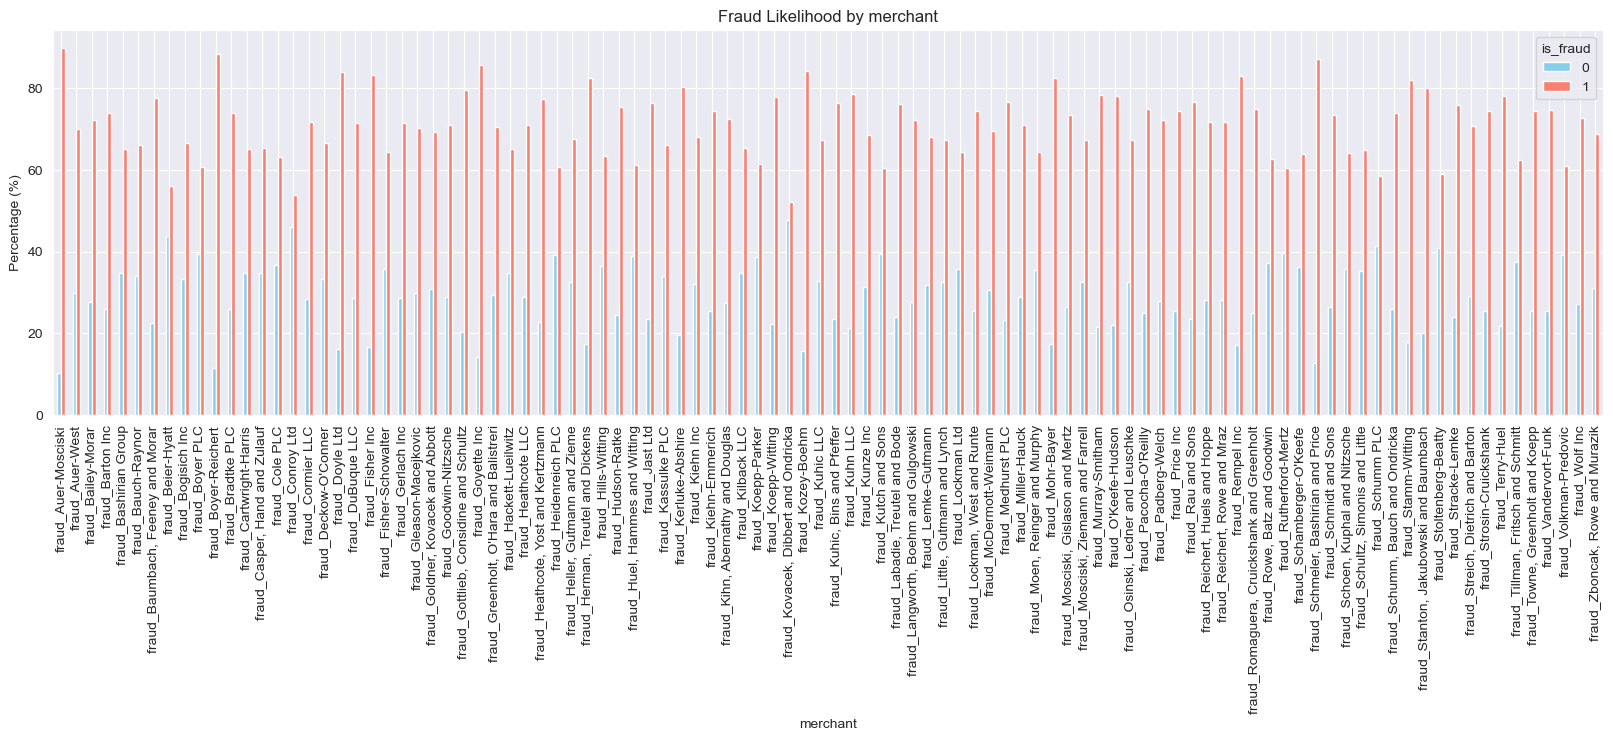

In [163]:

sample_and_plot(plot_df ,'merchant',20,100)

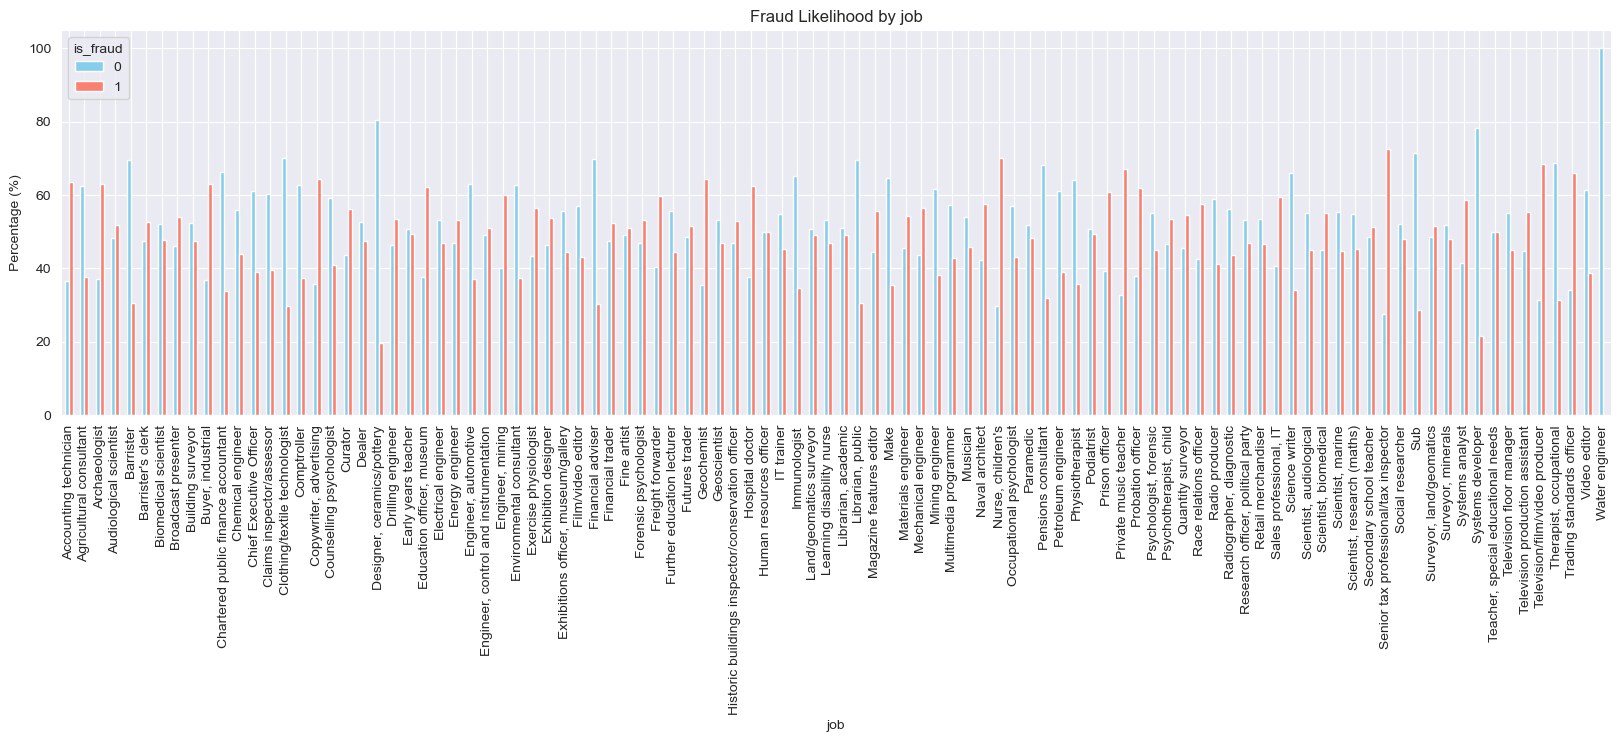

In [164]:

sample_and_plot(plot_df ,'job',20,100)

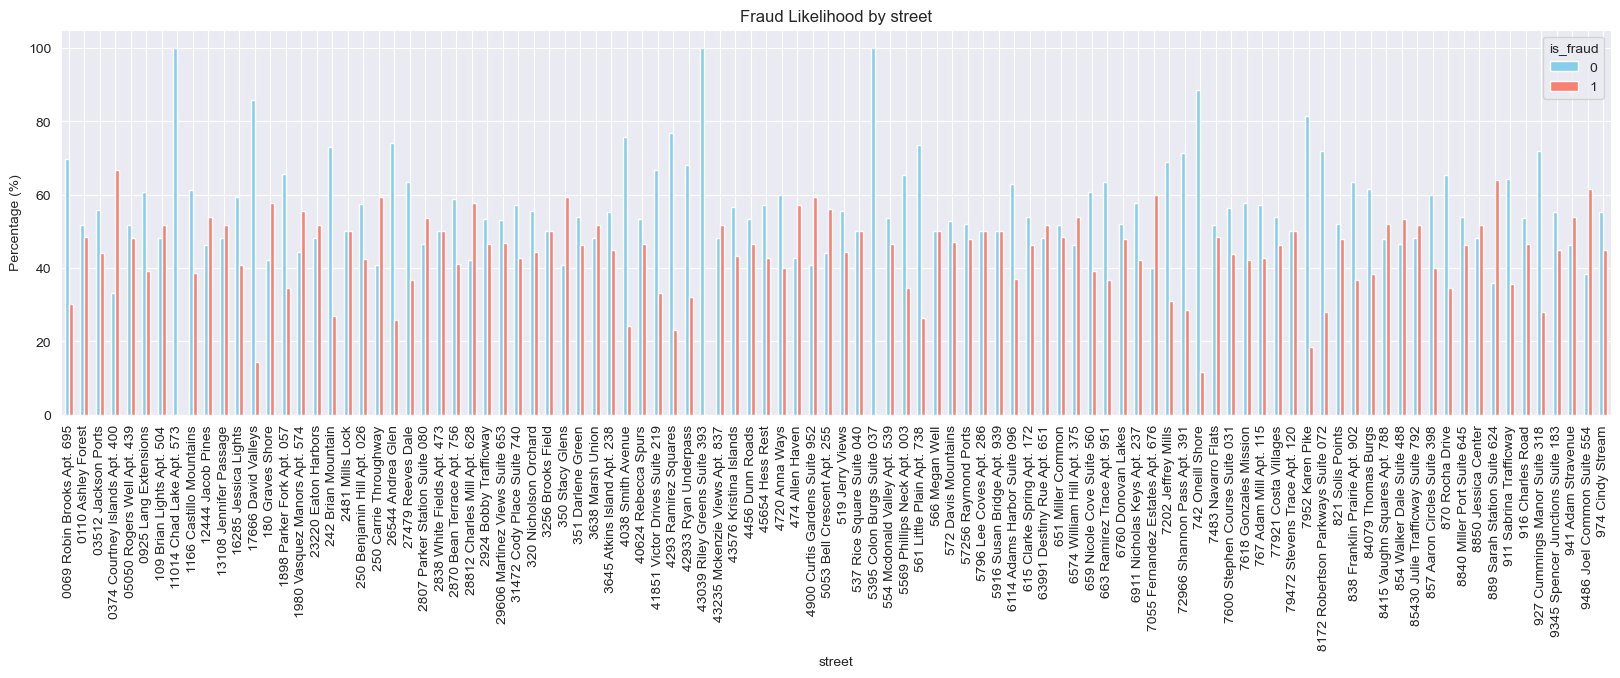

In [165]:
sample_and_plot(plot_df ,'street',20,100)

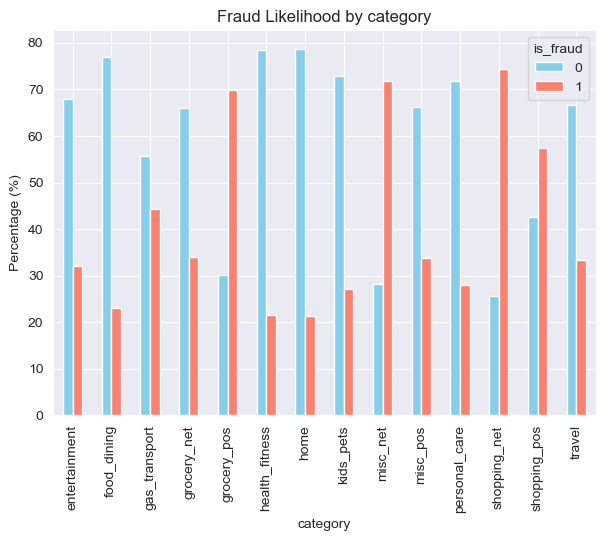

In [166]:
plot_bar(plot_df,"category")

In [167]:

plot_df['dob'] = pd.to_datetime(plot_df['dob'])
today = pd.to_datetime(date.today())
plot_df['age'] = (today - plot_df['dob']).dt.days // 365
plot_df["age"]

459030     28
202702     70
81563      34
427920     28
271479     25
           ..
681357     64
346565     67
1019514    58
282315     41
1071030    66
Name: age, Length: 15012, dtype: int64

<Axes: >

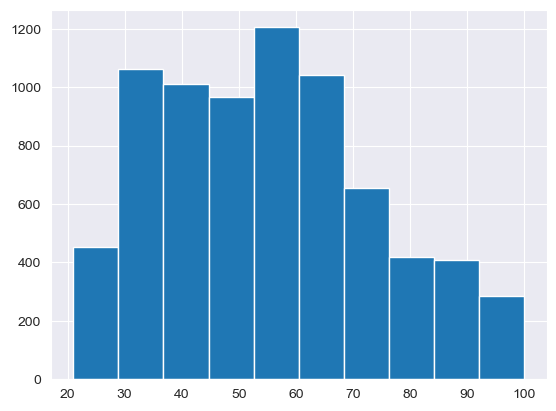

In [168]:
plot_df[plot_df["is_fraud"]==1]["age"].hist()

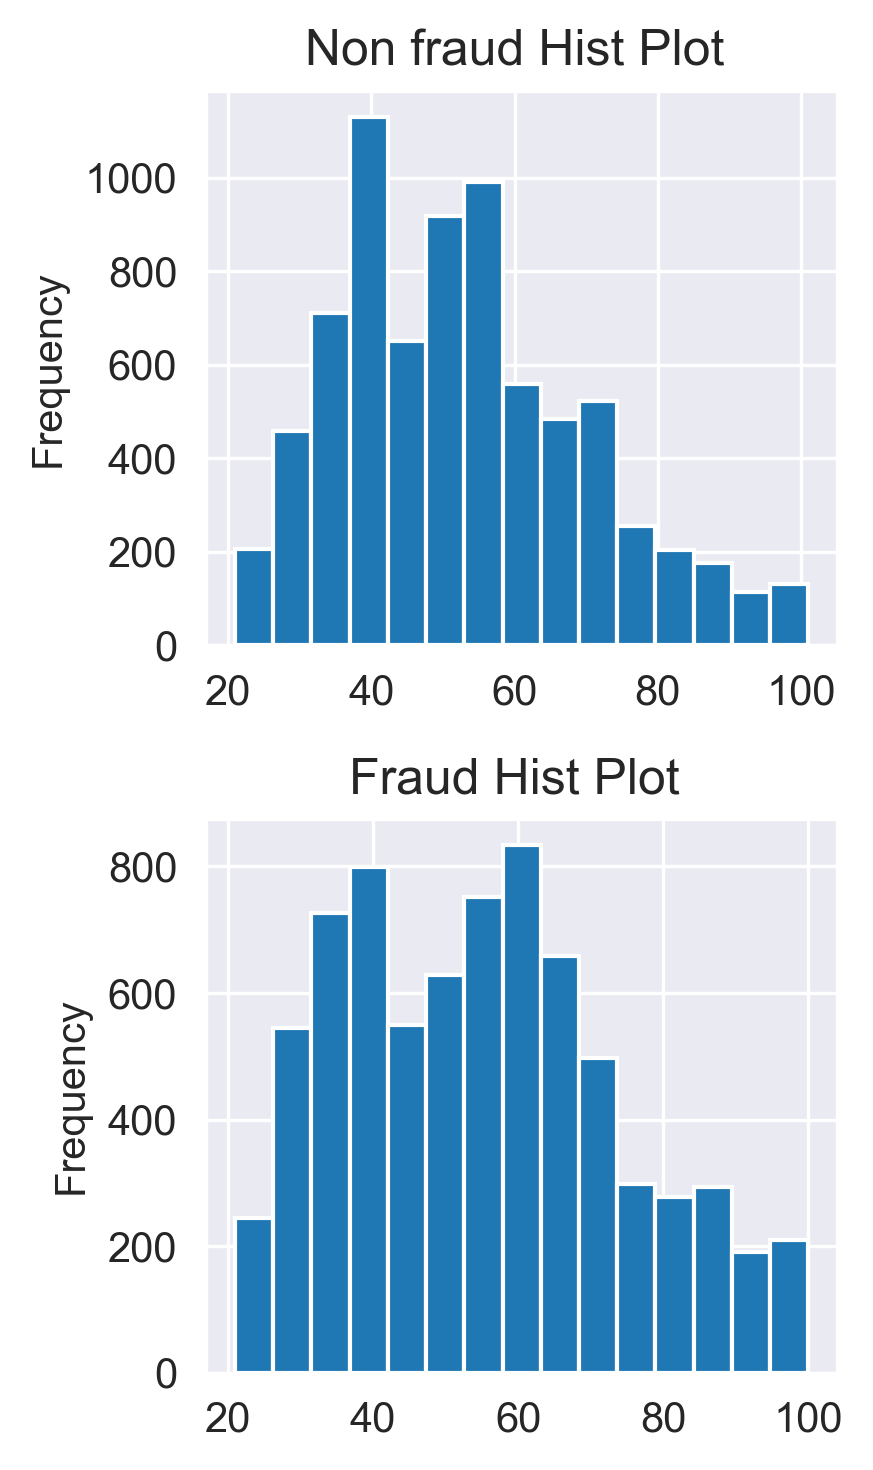

In [200]:
fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1,figsize=(3,5),dpi=300)
(plot_df[plot_df["is_fraud"]==0]["age"].plot(kind='hist', ax=ax1, bins=15))
fig.set_label("Age distribution for non fraud transactions")
ax1.set_title('Non fraud Hist Plot ')

(plot_df[plot_df["is_fraud"]==1]["age"].plot(kind='hist', ax=ax2, bins=15))
fig.set_label('Age distribution for fraud transactions')
ax2.set_title('Fraud Hist Plot ')


plt.tight_layout()
plt.show()


<Axes: >

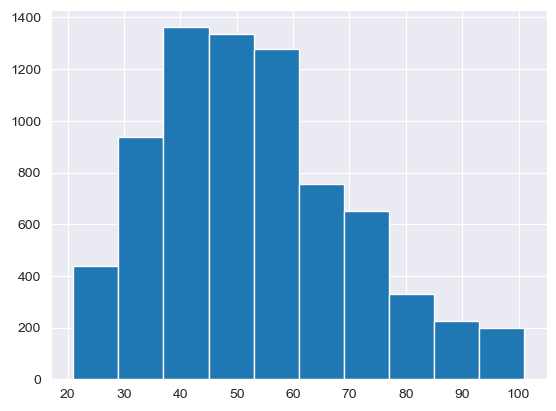

In [169]:
plot_df[plot_df["is_fraud"]==0]["age"].hist()

In [170]:
date_time = pd.to_datetime(plot_df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

plot_df['day_of_week'] = date_time.dt.day_of_week
plot_df['day_of_month'] = date_time.dt.day
plot_df['time_of_day'] = date_time.dt.hour
plot_df['month'] = date_time.dt.month

plot_df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,city_pop,job,dob,is_fraud,distance_km,age,day_of_week,day_of_month,time_of_day,month
459030,2019-07-22 00:06:42,2283743876903625,fraud_Ledner-Pfannerstill,gas_transport,13.80,F,9345 Spencer Junctions Suite 183,Alpharetta,GA,30009,...,165556,Prison officer,1997-12-27,1,95.855342,28,0,22,0,7
202702,2019-04-14 08:02:40,4277232699798846,"fraud_Jenkins, Hauck and Friesen",gas_transport,49.55,F,13299 Patrick Terrace,Rhame,ND,58651,...,475,Illustrator,1955-11-10,0,21.284747,70,6,14,8,4
81563,2019-02-18 00:18:41,3540210836308425,fraud_Kilback LLC,grocery_pos,283.61,M,94975 David Mews Apt. 316,Summerfield,TX,79085,...,53,Fisheries officer,1992-06-19,1,125.517716,34,0,18,0,2
427920,2019-07-11 04:38:23,577588686219,fraud_Roob LLC,grocery_net,37.65,M,25454 Leonard Lake,Spring Church,PA,15686,...,972,Public relations account executive,1997-10-23,0,22.366114,28,3,11,4,7
271479,2019-05-14 01:31:41,3575540972310993,fraud_Miller-Harris,misc_net,690.66,F,250 Carrie Throughway,University,MS,38677,...,4198,Curator,2001-06-22,1,101.618140,25,1,14,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681357,2019-10-17 22:32:25,502049568400,fraud_Kozey-McDermott,travel,1.51,M,6157 Nichols Mews,Marion,CT,6444,...,370,Health service manager,1962-02-13,1,76.999133,64,3,17,22,10
346565,2019-06-11 23:44:22,501828204849,"fraud_Schmeler, Bashirian and Price",shopping_net,955.86,F,31954 Eugene Lane Suite 572,Dexter,KS,67038,...,602,"Buyer, industrial",1958-10-26,1,101.586088,67,1,11,23,6
1019514,2020-02-24 22:56:47,3514865930894695,"fraud_Tillman, Fritsch and Schmitt",misc_net,759.92,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,...,899,Naval architect,1967-08-30,1,61.653515,58,0,24,22,2
282315,2019-05-19 13:24:12,6502195877055606,"fraud_Stanton, Jakubowski and Baumbach",shopping_net,1007.47,M,155 Gregory Mount Suite 791,Red Cliff,CO,81649,...,277,Human resources officer,1985-04-03,1,28.389509,41,6,19,13,5


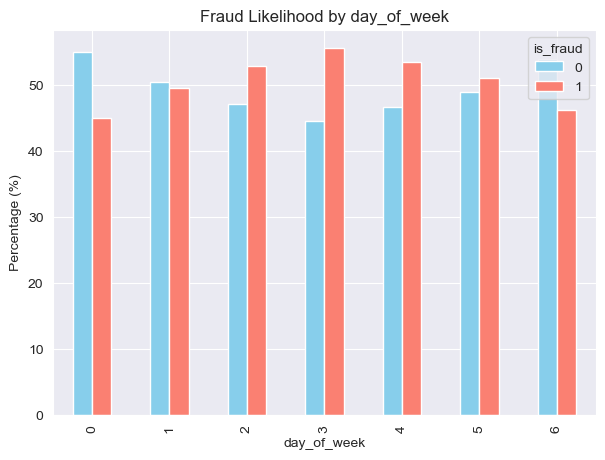

In [171]:
plot_bar(plot_df,"day_of_week")

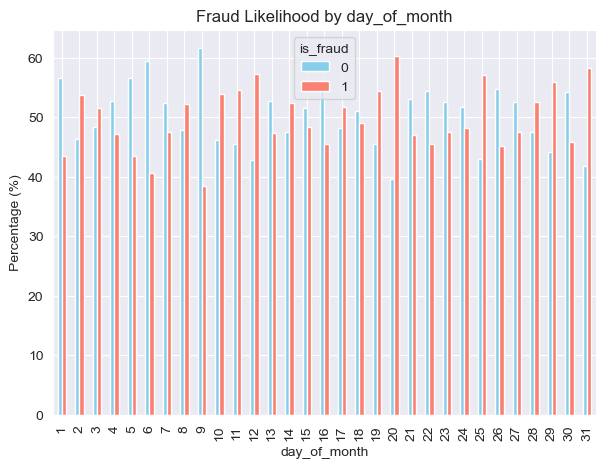

In [172]:
plot_bar(plot_df,"day_of_month")

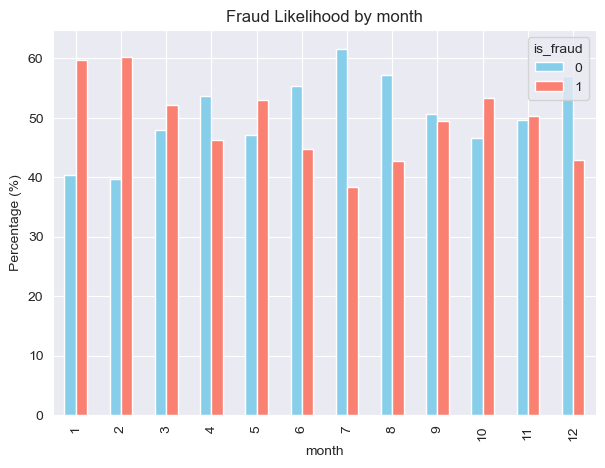

In [173]:
plot_bar(plot_df,"month")

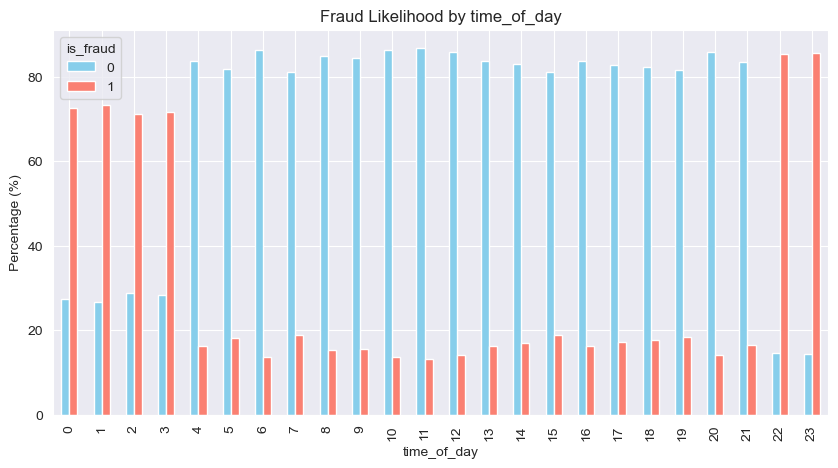

In [186]:

plot_bar(plot_df,"time_of_day",width=10)

array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>],
       [<Axes: title={'center': 'zip'}>, <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>]], dtype=object)

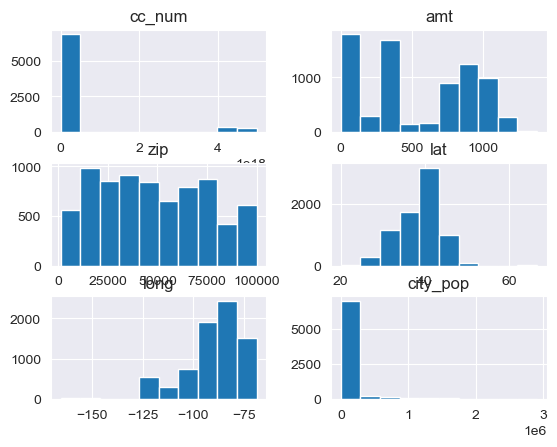

In [175]:
plot_df[plot_df["is_fraud"]==1][['cc_num','amt','zip','lat',"long" ,"city_pop"]].hist()


array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>],
       [<Axes: title={'center': 'zip'}>, <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>]], dtype=object)

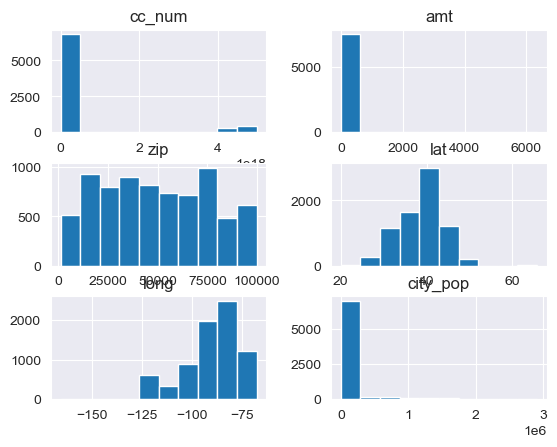

In [176]:
plot_df[plot_df["is_fraud"]==0][['cc_num','amt','zip','lat',"long" ,"city_pop"]].hist()


array([[<Axes: title={'center': 'distance_km'}>]], dtype=object)

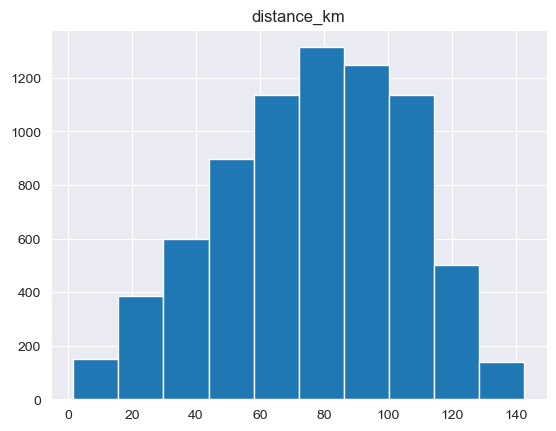

In [177]:
plot_df[plot_df["is_fraud"]==0][["distance_km"]].hist()

array([[<Axes: title={'center': 'distance_km'}>]], dtype=object)

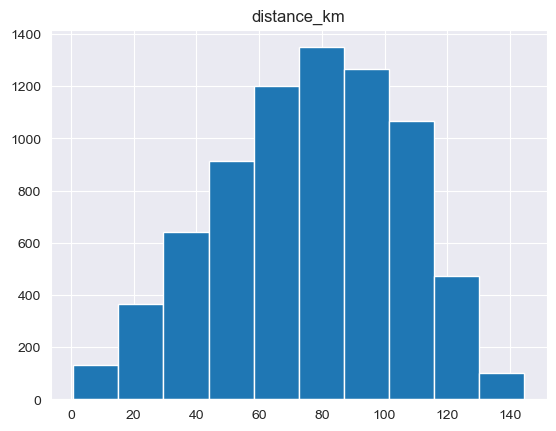

In [178]:
plot_df[plot_df["is_fraud"]==1][["distance_km"]].hist()


In [179]:
data["city"].value_counts()


city
Birmingham     5617
San Antonio    5130
Utica          5105
Phoenix        5075
Meridian       5060
               ... 
Norfolk           7
Karns City        7
Streator          7
Claypool          7
Bruce             7
Name: count, Length: 894, dtype: int64

In [180]:


def get_cramers_v(var1, var2):
    # Build the contingency table
    crosstab = pd.crosstab(var1, var2)
    
    # Get Chi-Square statistic
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    
    # Calculate Cramer's V
    return np.sqrt(phi2 / min(k - 1, r - 1))


In [181]:
# 1. Identify your categorical columns
cat_cols = plot_df.select_dtypes(include=['object', 'category']).drop(columns=["trans_date_trans_time"])

cat_cols = pd.concat([cat_cols , pd.DataFrame(plot_df["is_fraud"])] , axis=1).columns



In [182]:
# 2. Initialize an empty matrix
v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

# 3. Nested Loop
for col1 in cat_cols:
    for col2 in cat_cols:
        v_matrix.loc[col1, col2] = get_cramers_v(plot_df[col1], plot_df[col2])

# Convert to float for visualization
v_matrix = v_matrix.astype(float)

In [183]:
results = {}
target = 'is_fraud'

for col in cat_cols:
    if col != target:
        results[col] = get_cramers_v(plot_df[col], plot_df[target])

# Convert to a sorted list for easy reading
sorted_features = pd.Series(results).sort_values(ascending=False)
print(sorted_features)

street      0.524024
city        0.497462
merchant    0.448198
category    0.409173
job         0.364336
state       0.106936
gender      0.048541
dtype: float64


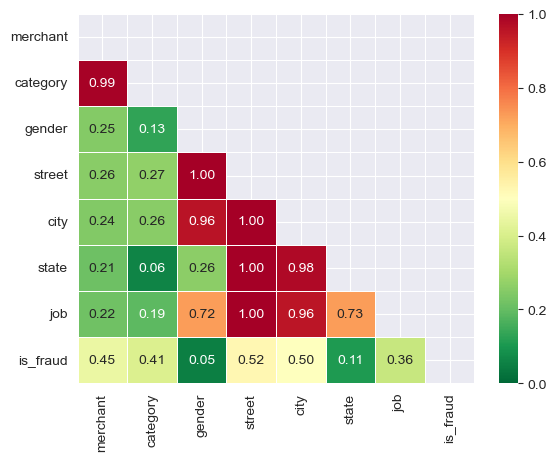

In [185]:
mask = np.triu(np.ones_like(v_matrix, dtype=bool))

sns.heatmap(v_matrix,
               mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",        # red = high correlation (bad), green = low
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 10},
            )
plt.savefig("cramers_v_heatmap.png", dpi=300, bbox_inches="tight")

In [88]:
v_matrix

,merchant,category,gender,street,city,state,job,is_fraud
merchant,1.000000,0.994726,0.247645,0.255755,0.244055,0.214042,0.215001,0.448198
category,0.994726,1.000000,0.131469,0.268774,0.256575,0.058805,0.189237,0.409173
gender,0.247645,0.131469,0.999867,1.000000,0.957848,0.258923,0.723889,0.048541
street,0.255755,0.268774,1.000000,1.000000,1.000000,1.000000,1.000000,0.524024
city,0.244055,0.256575,0.957848,1.000000,1.000000,0.978812,0.955758,0.497462
state,0.214042,0.058805,0.258923,1.000000,0.978812,1.000000,0.725265,0.106936
job,0.215001,0.189237,0.723889,1.000000,0.955758,0.725265,1.000000,0.364336
is_fraud,0.448198,0.409173,0.048541,0.524024,0.497462,0.106936,0.364336,0.999867


merchant and category are highly correlated , favor category for more information with less labels 

In [89]:
gender_diversity = plot_df.groupby('street')['gender'].nunique()
print(gender_diversity.value_counts())

gender
1    977
Name: count, dtype: int64


street and gender have a perfect cramer's v score , and inspecting the data reveals there is only 1 gender per street in this dataset 
conclusion : street should be dropped 

street, city, state, zip, job should be dropped because of perfect correlation , they essentially act as ids for each other 

categorical features left : category ,gender

In [90]:
dummies = pd.get_dummies(plot_df["category"], prefix="category",dtype=int)
g_dummies = pd.get_dummies(plot_df["gender"], prefix="gender",dtype=int)
df = pd.concat([plot_df , dummies], axis=1)
df = add_velocity_features(df)
df = df.drop(columns=["merchant","street","city","state","job","cc_num","city_pop","trans_date_trans_time","zip","lat","long","dob","category","gender"])
df.dtypes

amt                        float64
is_fraud                     int64
distance_km                float64
age                          int64
day_of_week                  int32
day_of_month                 int32
time_of_day                  int32
month                        int32
category_entertainment       int64
category_food_dining         int64
category_gas_transport       int64
category_grocery_net         int64
category_grocery_pos         int64
category_health_fitness      int64
category_home                int64
category_kids_pets           int64
category_misc_net            int64
category_misc_pos            int64
category_personal_care       int64
category_shopping_net        int64
category_shopping_pos        int64
category_travel              int64
tx_count_1h                float64
tx_count_24h               float64
amt_sum_24h                float64
dtype: object

In [92]:
plot_df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,city_pop,job,dob,is_fraud,distance_km,age,day_of_week,day_of_month,time_of_day,month
541433,2019-08-19 20:11:11,4972228199573984,"fraud_O'Reilly, Mohr and Purdy",home,58.85,M,3316 Cindy Land,Lane,OK,74555,...,861,Quantity surveyor,1960-04-08,0,114.736386,66,0,19,20,8
395924,2019-06-29 23:37:13,4308156300921054,fraud_Schmidt and Sons,shopping_net,1153.57,M,454 Sawyer Forks Apt. 231,Collegeville,MN,56321,...,1536,Farm manager,1981-02-18,1,31.806325,45,5,29,23,6
216782,2019-04-20 17:48:44,3596357274378601,fraud_Schmidt-Larkin,home,119.59,M,4138 David Fall,Morrisdale,PA,16858,...,3688,Advice worker,1973-05-27,0,108.825764,53,5,20,17,4
1022652,2020-02-27 13:29:51,4939976756738216,"fraud_Roob, Conn and Tremblay",shopping_pos,6.37,F,3531 Hamilton Highway,Roma,TX,78584,...,18128,IT trainer,1990-11-07,0,69.779749,35,3,27,13,2
30248,2019-01-18 23:31:25,372246459334925,fraud_Ullrich Ltd,kids_pets,6.06,M,062 Poole Hollow Apt. 815,Deadwood,SD,57732,...,1979,Multimedia programmer,1970-03-13,1,58.534358,56,4,18,23,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139174,2020-04-19 22:36:05,3590946339258737,fraud_Boyer-Reichert,shopping_net,780.73,M,741 Adams Knolls,Grenola,KS,67346,...,372,"Copywriter, advertising",1997-04-06,1,89.173788,29,6,19,22,4
21831,2019-01-14 01:41:08,4979422371139333,fraud_Cassin-Harvey,grocery_net,16.44,F,1893 Katie Tunnel,Westerville,NE,68881,...,73,Product designer,1935-02-10,1,64.085327,91,0,14,1,1
1021862,2020-02-26 21:23:23,340953839692349,"fraud_Reichert, Huels and Hoppe",shopping_net,5.64,M,615 Clarke Spring Apt. 172,Warren,MI,48088,...,134056,"Doctor, hospital",1980-05-18,0,42.323716,46,2,26,21,2
540936,2019-08-19 17:30:50,4328928491302401,fraud_Wuckert-Goldner,home,210.79,F,927 Cummings Manor Suite 318,Greendale,WI,53129,...,13973,Logistics and distribution manager,1981-05-06,0,71.978586,45,0,19,17,8


In [93]:

# Identify which columns are categorical (True/False list)
# Assume X is your DataFrame
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# Mark integer/bool columns as discrete and float columns as continuous
discrete_mask = X.dtypes.apply(lambda dt: pd.api.types.is_integer_dtype(dt) or pd.api.types.is_bool_dtype(dt)).to_numpy()

# Run the calculation
scores = mutual_info_classif(X, y, discrete_features=discrete_mask)

# Create a ranking
mi_results = pd.Series(scores, index=X.columns).sort_values(ascending=False)

mi_results

amt_sum_24h                0.586921
tx_count_24h               0.489466
amt                        0.460003
time_of_day                0.223617
tx_count_1h                0.185299
category_shopping_net      0.022200
age                        0.018632
category_grocery_pos       0.016133
category_home              0.011604
category_misc_net          0.009069
month                      0.008166
category_health_fitness    0.007319
category_food_dining       0.007066
category_kids_pets         0.006757
category_personal_care     0.005454
day_of_month               0.005303
category_entertainment     0.003329
category_misc_pos          0.002774
day_of_week                0.002645
category_grocery_net       0.001383
category_travel            0.001324
category_shopping_pos      0.001199
category_gas_transport     0.000651
distance_km                0.000000
dtype: float64

In [94]:
df

,amt,is_fraud,distance_km,age,day_of_week,day_of_month,time_of_day,month,category_entertainment,category_food_dining,...,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,tx_count_1h,tx_count_24h,amt_sum_24h
0,186.65,0,41.503887,44,5,16,4,2,0,0,...,0,0,0,0,0,0,0,1.0,1.0,186.65
0,711.63,1,121.380484,29,5,19,3,10,0,0,...,0,1,0,0,0,0,0,1.0,1.0,711.63
0,3.38,0,42.319149,53,6,20,6,1,0,0,...,0,1,0,0,0,0,0,1.0,1.0,3.38
0,61.76,0,118.879120,63,6,10,6,3,0,0,...,0,0,0,0,0,0,0,1.0,1.0,61.76
0,911.75,1,82.296594,24,1,12,0,2,0,0,...,0,1,0,0,0,0,0,1.0,1.0,911.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,6.65,0,72.827563,26,1,19,21,5,0,0,...,0,0,0,0,1,0,0,1.0,1.0,6.65
34,69.19,0,47.515861,54,0,27,18,4,0,0,...,1,0,0,0,0,0,0,1.0,1.0,69.19
35,7.42,0,64.734734,54,4,12,15,6,0,0,...,1,0,0,0,0,0,0,1.0,1.0,7.42
36,1.31,0,86.842484,54,1,16,21,6,0,0,...,0,0,0,0,0,1,0,1.0,1.0,1.31


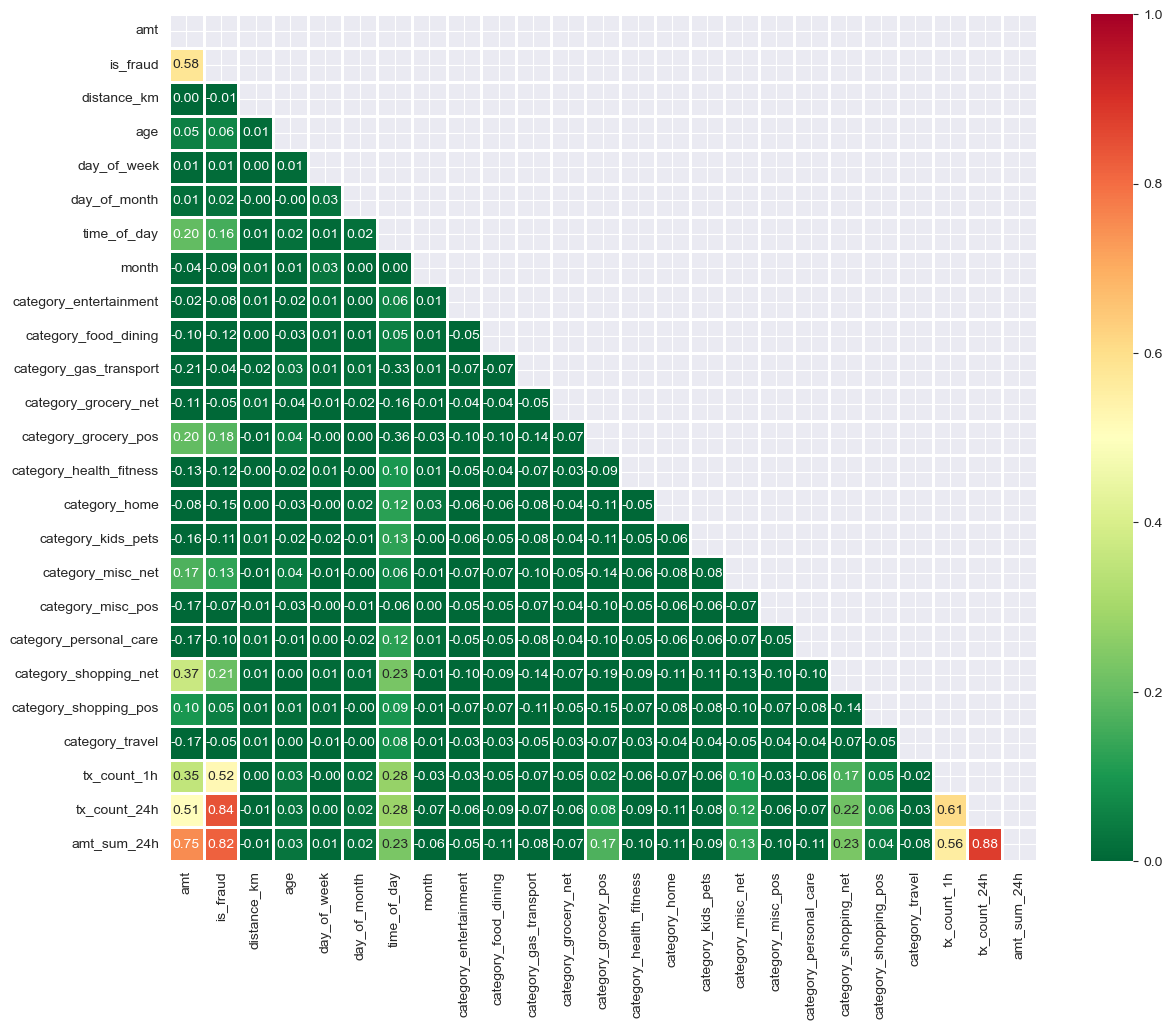

In [99]:
matrix = df.corr(method="spearman")
mask = np.triu(np.ones_like(matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(matrix,
               mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",        # red = high correlation (bad), green = low
    vmin=0, vmax=1,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 10},
            ax=ax)
plt.savefig("cramers_v_heatmap.png", dpi=300, bbox_inches="tight")

In [47]:


ct = ColumnTransformer(
    [("low_card_cat",OneHotEncoder(),["category","gender","state"]),
     ("high_card_cat",JamesSteinEncoder(),["merchant","street","city","job"])
     ],remainder="passthrough"
)

plot_df = add_velocity_features(plot_df)

final_test_df = ct.fit_transform(plot_df.drop(columns=["is_fraud","trans_date_trans_time","dob"]),plot_df["is_fraud"])


In [48]:



rf = RandomForestClassifier()
rf.fit(final_test_df,plot_df["is_fraud"])




RandomForestClassifier()

In [49]:
data = pd.read_csv("./fraudTest.csv", index_col=0)

In [51]:
date_time = pd.to_datetime(data['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

data['day_of_week'] = date_time.dt.day_of_week
data['day_of_month'] = date_time.dt.day
data['time_of_day'] = date_time.dt.hour
data['month'] = date_time.dt.month


data['dob'] = pd.to_datetime(data['dob'])
today = pd.to_datetime(date.today())
data['age'] = (today - data['dob']).dt.days // 365
data["age"]
data['distance_km'] = haversine_vectorized(data['lat'], data['long'], data['merch_lat'], data['merch_long'])

data = add_velocity_features(data)
X_test = data.drop(columns=["is_fraud", "trans_date_trans_time", "dob"])
y_test = data["is_fraud"]

X_test = ct.transform(X_test)

In [ ]:
preds = rf.predict(X_test)

In [161]:
rf.score(X_test,y_test)

0.42114629875890514

In [162]:
from sklearn.metrics import classification_report
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       1.00      0.42      0.59    553574
           1       0.00      0.69      0.01      2145

    accuracy                           0.42    555719
   macro avg       0.50      0.56      0.30    555719
weighted avg       0.99      0.42      0.59    555719



In [163]:

# 1. Get feature names from the transformer
feature_names = ct.get_feature_names_out()

# 2. Get importance scores from the model
importances = rf.feature_importances_

# 3. Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

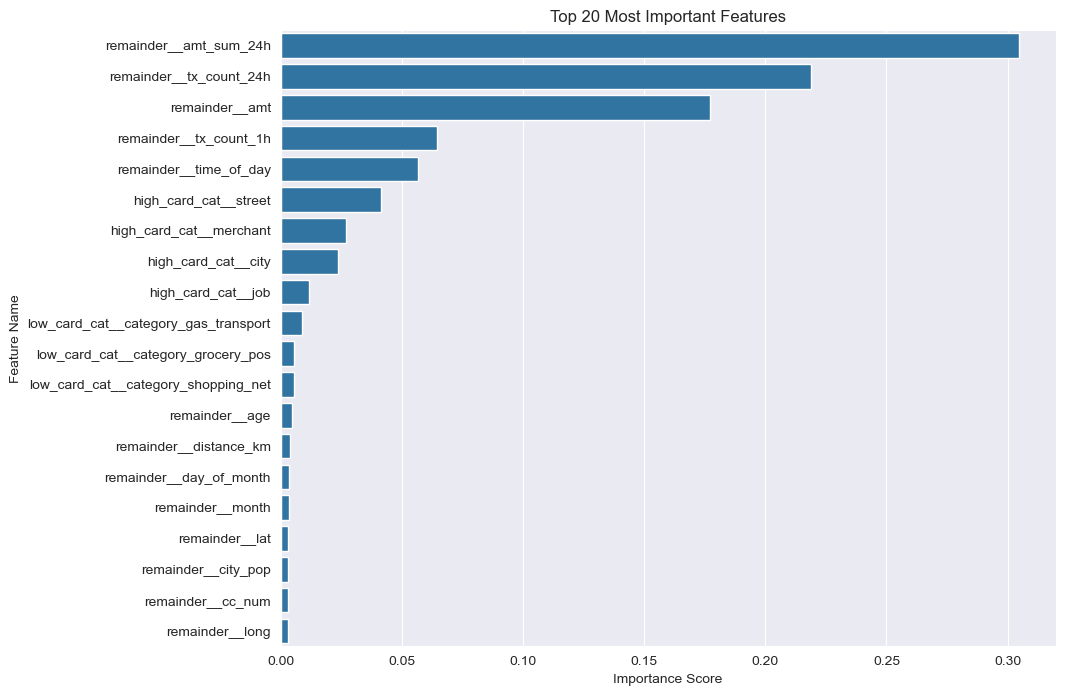

In [164]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(20)) # Show top 20
plt.title('Top 20 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()